In [1]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
%matplotlib inline
from IPython.display import clear_output

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_folder = "drive/MyDrive/mestrado_final_files/models/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_folder = "G:\Meu Drive\mestrado_final_files\models\\"

In [2]:
print(f"Pandas version: {pd.__version__},\nNumpy Version: {np.__version__},\
      \nTorch Version: {torch.__version__},\nMatplotlib Version: {plt.matplotlib.__version__}")

Pandas version: 2.2.3,
Numpy Version: 2.2.6,      
Torch Version: 2.8.0+cpu,
Matplotlib Version: 3.10.0


In [3]:
pd.set_option("display.expand_frame_repr", False)

In [4]:
df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')\
[['GAME_ID', 'HOME_TEAM_ID', 'AWAY_TEAM_ID', 'HOME_TEAM', 'AWAY_TEAM', 'GAME_DATE', 'HOME_PTS', 'AWAY_PTS']]

columns_boxscore = ["home_FGM", "away_FGM", "home_FGA", "away_FGA", "home_FGP", "away_FGP", 
                    "home_3FGM", "away_3FGM", "home_3FGA", "away_3FGA", "home_3FGP", "away_3FGP", 
                    "home_FTM", "away_FTM", "home_FTA", "away_FTA", "home_FTP", "away_FTP", 
                    "home_RebOff", "away_RebOff", "home_RebDef", "away_RebDef", "home_RebTot", 
                    "away_RebTot", "home_AST", "away_AST", "home_STL", "away_STL", "home_BLK", 
                    "away_BLK", "home_TO", "away_TO", "home_FP", "away_FP", "home_points", 
                    "away_points", "home_PMP", "away_PMP", "home_outcome", 'away_outcome']

df_boxscore = pd.read_csv(data_folder + 'boxscore_moving_average20.txt', sep = ';')\
.set_index("game_id")\
[columns_boxscore]

In [5]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [6]:
full_covariables = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 'limhfouls', 'limvfouls', 'dif', 'dif_20', 'ind_close_3',
                    'ind_close_5', 'ind_close_8', 'ind_blowout_15', 'ind_last_2_minutes', 'ind_last_minute', 'ind_last_20_seconds', 'ind_last_10_seconds', 
                    'lead', 'home_lead', 'away_lead', 'ind_last_2_minutes_game', 'ind_last_minute_game', 'ind_last_20_seconds_game', 
                    'ind_last_10_seconds_game', 'ind_clutch_2_last_minutes', 'ind_clutch_2_last_minutes_home', 'ind_clutch_2_last_minutes_away',
                    'ind_clutch_last_minute', 'ind_clutch_last_minute_home', 'ind_clutch_last_minute_away', 'ind_clutch_last_20_seconds',
                    'ind_clutch_last_20_seconds_home', 'ind_clutch_last_20_seconds_away', 'ind_clutch_last_10_seconds', 'ind_clutch_last_10_seconds_home',
                    'ind_clutch_last_10_seconds_away', 'ind_blowout_last_minute', 'ball_possession', 'home_FGM', 'away_FGM', 'home_FGA', 'away_FGA', 
                    'home_FGP', 'away_FGP', 'home_3FGM', 'away_3FGM', 'home_3FGA', 'away_3FGA', 'home_3FGP', 'away_3FGP', 'home_FTM', 'away_FTM', 
                    'home_FTA', 'away_FTA', 'home_FTP', 'away_FTP', 'home_RebOff', 'away_RebOff', 'home_RebDef', 'away_RebDef', 'home_RebTot', 
                    'away_RebTot', 'home_AST', 'away_AST', 'home_STL', 'away_STL', 'home_BLK', 'away_BLK', 'home_TO', 'away_TO', 'home_FP', 
                    'away_FP', 'home_points', 'away_points', 'home_PMP', 'away_PMP', 'home_outcome', 'away_outcome', 'playoff_game']

old_covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 
                         'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 'ind_last_20_seconds', 
                         'ind_last_10_seconds', 'lead', 'ball_possession']

new_covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 'limhfouls', 'limvfouls', 'dif_20', 'ind_close_3',
                         'ind_close_5', 'ind_close_8', 'ind_blowout_15', 'ind_last_2_minutes', 'ind_last_minute', 'ind_last_20_seconds', 'ind_last_10_seconds', 
                         'home_lead', 'away_lead', 'ind_last_2_minutes_game', 'ind_last_minute_game', 'ind_last_20_seconds_game', 
                         'ind_last_10_seconds_game', 'ind_clutch_2_last_minutes', 'ind_clutch_2_last_minutes_home', 'ind_clutch_2_last_minutes_away',
                         'ind_clutch_last_minute', 'ind_clutch_last_minute_home', 'ind_clutch_last_minute_away', 'ind_clutch_last_20_seconds',
                         'ind_clutch_last_20_seconds_home', 'ind_clutch_last_20_seconds_away', 'ind_clutch_last_10_seconds', 'ind_clutch_last_10_seconds_home',
                         'ind_clutch_last_10_seconds_away', 'ind_blowout_last_minute', 'ball_possession']

old_index_covariables = [i for i, var in enumerate(full_covariables) if var in old_covariables_model]
new_index_covariables = [i for i, var in enumerate(full_covariables) if var in new_covariables_model]


In [7]:
%run 02_functions_simulations.ipynb

In [8]:
CONTEXT_SIZE = 5
EMBEDDING_LAYER_SIZE = 32
VOCAB_SIZE = 601
TIME_SIZE = 301


In [9]:
model_file = models_folder + 'ngram_token_model_season_201819_dropout03_parameters.pth'

old_token_model_201819 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(old_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

old_token_model_201819.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_token_model_201819.eval()

model_file = models_folder + 'ngram_time_model_season_201819_dropout03_parameters.pth'

old_time_model_201819 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(old_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

old_time_model_201819.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_time_model_201819.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [10]:
model_file = models_folder + 'ngram_token_model_season_201819_dropout03_new_variables_parameters.pth'

new_token_model_201819 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(new_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

new_token_model_201819.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_token_model_201819.eval()

model_file = models_folder + 'ngram_time_model_season_201819_dropout03_new_variables_parameters.pth'

new_time_model_201819 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(new_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

new_time_model_201819.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_time_model_201819.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=197, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [11]:
df_simulations_201819_old = generate_game_plays(token_model = old_token_model_201819, time_model = old_time_model_201819, num_simulations = 50000, token_context = 5, num_numerical_variables = 14, config = 1)

Period: 8
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  111.77916  11.936431  64.0  85.0  92.0  97.0  104.0  112.0  120.0  127.0  132.0  140.0  166.0
away_points       50000  109.41194  11.714057  61.0  83.0  90.0  95.0  101.0  109.0  117.0  125.0  129.0  137.0  161.0
perc_played_time  50000    0.00200   0.447209   0.0   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 22195, np.str_('home'): 27805}


In [12]:
df_simulations_201819_old.to_csv(path_or_buf = data_folder + "old_model_simulations_variation_problem_201819.csv", sep = ";", index = False)

In [13]:
del df_simulations_201819_old

In [14]:
df_simulations_201819_new = generate_game_plays(token_model = new_token_model_201819, time_model = new_time_model_201819, num_simulations = 50000, token_context = 5, num_numerical_variables = 37, config = 2)

Period: 7
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%    10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  110.68746  10.817135  65.0  86.0  93.0   97.0  103.0  111.0  118.0  124.0  128.0  136.0  164.0
away_points       50000  113.01098  10.728015  66.0  89.0  96.0  100.0  106.0  113.0  120.0  127.0  131.0  139.0  161.0
perc_played_time  50000    0.01800   1.341520   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 26422, np.str_('home'): 23578}


In [15]:
df_simulations_201819_new.to_csv(path_or_buf = data_folder + "new_model_simulations_variation_problem_201819.csv", sep = ";", index = False)

In [16]:
del df_simulations_201819_new

In [17]:
del old_token_model_201819, old_time_model_201819, new_token_model_201819, new_time_model_201819

In [18]:
model_file = models_folder + 'ngram_token_model_season_201920_dropout03_parameters.pth'

old_token_model_201920 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(old_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

old_token_model_201920.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_token_model_201920.eval()

model_file = models_folder + 'ngram_time_model_season_201920_dropout03_parameters.pth'

old_time_model_201920 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(old_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

old_time_model_201920.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_time_model_201920.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [19]:
model_file = models_folder + 'ngram_token_model_season_201920_dropout03_new_variables_parameters.pth'

new_token_model_201920 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(new_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

new_token_model_201920.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_token_model_201920.eval()

model_file = models_folder + 'ngram_time_model_season_201920_dropout03_new_variables_parameters.pth'

new_time_model_201920 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(new_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

new_time_model_201920.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_time_model_201920.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=197, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [20]:
df_simulations_201920_old = generate_game_plays(token_model = old_token_model_201920, time_model = old_time_model_201920, num_simulations = 50000, token_context = 5, num_numerical_variables = 14, config = 1)

Period: 7
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  112.28302  12.014724  62.0  85.0  93.0  97.0  104.0  112.0  120.0  128.0  132.0  141.0  163.0
away_points       50000  110.36308  11.862998  64.0  84.0  91.0  95.0  102.0  110.0  118.0  126.0  130.0  139.0  170.0
perc_played_time  50000    0.00600   0.774573   0.0   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 22805, np.str_('home'): 27195}


In [21]:
df_simulations_201920_old.to_csv(path_or_buf = data_folder + "old_model_simulations_variation_problem_201920.csv", sep = ";", index = False)

In [22]:
del df_simulations_201920_old

In [23]:
df_simulations_201920_new = generate_game_plays(token_model = new_token_model_201920, time_model = new_time_model_201920, num_simulations = 50000, token_context = 5, num_numerical_variables = 37, config = 2)

Period: 8
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  110.99678  15.842701  49.0  75.0  84.0  90.0  100.0  112.0  122.0  131.0  136.0  147.0  172.0
away_points       50000  110.83342   9.521819  74.0  89.0  96.0  99.0  104.0  111.0  117.0  123.0  127.0  134.0  168.0
perc_played_time  50000    0.00200   0.447209   0.0   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 24509, np.str_('home'): 25491}


In [24]:
df_simulations_201920_new.to_csv(path_or_buf = data_folder + "new_model_simulations_variation_problem_201920.csv", sep = ";", index = False)

In [25]:
del df_simulations_201920_new

In [26]:
del old_token_model_201920, old_time_model_201920, new_token_model_201920, new_time_model_201920

In [27]:
model_file = models_folder + 'ngram_token_model_season_202021_dropout03_parameters.pth'

old_token_model_202021 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(old_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

old_token_model_202021.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_token_model_202021.eval()

model_file = models_folder + 'ngram_time_model_season_202021_dropout03_parameters.pth'

old_time_model_202021 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(old_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

old_time_model_202021.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_time_model_202021.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [28]:
model_file = models_folder + 'ngram_token_model_season_202021_dropout03_new_variables_parameters.pth'

new_token_model_202021 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(new_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

new_token_model_202021.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_token_model_202021.eval()

model_file = models_folder + 'ngram_time_model_season_202021_dropout03_new_variables_parameters.pth'

new_time_model_202021 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(new_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

new_time_model_202021.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_time_model_202021.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=197, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [29]:
df_simulations_202021_old = generate_game_plays(token_model = old_token_model_202021, time_model = old_time_model_202021, num_simulations = 50000, token_context = 5, num_numerical_variables = 14, config = 1)

Period: 7
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  112.38188  11.953445  62.0  85.0  93.0  97.0  104.0  112.0  120.0  128.0  132.0  140.0  165.0
away_points       50000  110.62596  11.678382  65.0  84.0  91.0  96.0  103.0  111.0  119.0  126.0  130.0  138.0  162.0
perc_played_time  50000    0.01200   1.095379   0.0   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 23008, np.str_('home'): 26992}


In [30]:
df_simulations_202021_old.to_csv(path_or_buf = data_folder + "old_model_simulations_variation_problem_202021.csv", sep = ";", index = False)

In [31]:
del df_simulations_202021_old

In [32]:
df_simulations_202021_new = generate_game_plays(token_model = new_token_model_202021, time_model = new_time_model_202021, num_simulations = 50000, token_context = 5, num_numerical_variables = 37, config = 2)

Period: 8
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%    10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  115.58836  12.152692  73.0  89.0  96.0  100.0  107.0  115.0  124.0  131.0  136.0  145.0  169.0
away_points       50000  114.15570  10.792637  66.0  90.0  97.0  100.0  107.0  114.0  121.0  128.0  132.0  140.0  168.0
perc_played_time  50000    0.00400   0.632443   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 23739, np.str_('home'): 26261}


In [33]:
df_simulations_202021_new.to_csv(path_or_buf = data_folder + "new_model_simulations_variation_problem_202021.csv", sep = ";", index = False)

In [34]:
del df_simulations_202021_new

In [35]:
del old_token_model_202021, old_time_model_202021, new_token_model_202021, new_time_model_202021

In [36]:
model_file = models_folder + 'ngram_token_model_season_202122_dropout03_parameters.pth'

old_token_model_202122 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(old_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

old_token_model_202122.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_token_model_202122.eval()

model_file = models_folder + 'ngram_time_model_season_202122_dropout03_parameters.pth'

old_time_model_202122 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(old_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

old_time_model_202122.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_time_model_202122.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [ ]:
model_file = models_folder + 'ngram_token_model_season_202122_dropout03_new_variables_parameters.pth'

new_token_model_202122 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(new_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

new_token_model_202122.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_token_model_202122.eval()

model_file = models_folder + 'ngram_time_model_season_202122_dropout03_new_variables_parameters.pth'

new_time_model_202122 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(new_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

new_time_model_202122.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_time_model_202122.eval()

In [38]:
df_simulations_202122_old = generate_game_plays(token_model = old_token_model_202122, time_model = old_time_model_202122, num_simulations = 50000, token_context = 5, num_numerical_variables = 14, config = 1)

Period: 8
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  111.87318  11.811260  68.0  85.0  93.0  97.0  104.0  112.0  120.0  127.0  132.0  140.0  163.0
away_points       50000  108.62482  11.784161  64.0  82.0  89.0  94.0  101.0  108.0  117.0  124.0  128.0  137.0  158.0
perc_played_time  50000    0.00200   0.447209   0.0   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 21197, np.str_('home'): 28803}


In [39]:
df_simulations_202122_old.to_csv(path_or_buf = data_folder + "old_model_simulations_variation_problem_202122.csv", sep = ";", index = False)

In [40]:
del df_simulations_202122_old

In [41]:
df_simulations_202122_new = generate_game_plays(token_model = new_token_model_202122, time_model = new_time_model_202122, num_simulations = 50000, token_context = 5, num_numerical_variables = 37, config = 2)

Period: 8
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min     1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  111.53502  10.830247  67.0  87.00  94.0  98.0  104.0  111.0  119.0  125.0  130.0  137.0  160.0
away_points       50000  109.14224  11.218747  61.0  83.99  91.0  95.0  102.0  109.0  117.0  123.0  128.0  136.0  158.0
perc_played_time  50000    0.00200   0.447209   0.0   0.00   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 21521, np.str_('home'): 28479}


In [42]:
df_simulations_202122_new.to_csv(path_or_buf = data_folder + "new_model_simulations_variation_problem_202122.csv", sep = ";", index = False)

In [43]:
del df_simulations_202122_new

In [44]:
del old_token_model_202122, old_time_model_202122, new_token_model_202122, new_time_model_202122

In [45]:
model_file = models_folder + 'ngram_token_model_season_202223_dropout03_parameters.pth'

old_token_model_202223 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(old_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

old_token_model_202223.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_token_model_202223.eval()

model_file = models_folder + 'ngram_time_model_season_202223_dropout03_parameters.pth'

old_time_model_202223 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(old_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

old_time_model_202223.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_time_model_202223.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [46]:
model_file = models_folder + 'ngram_token_model_season_202223_dropout03_new_variables_parameters.pth'

new_token_model_202223 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(new_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

new_token_model_202223.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_token_model_202223.eval()

model_file = models_folder + 'ngram_time_model_season_202223_dropout03_new_variables_parameters.pth'

new_time_model_202223 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(new_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

new_time_model_202223.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_time_model_202223.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=197, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [47]:
df_simulations_202223_old = generate_game_plays(token_model = old_token_model_202223, time_model = old_time_model_202223, num_simulations = 50000, token_context = 5, num_numerical_variables = 14, config = 1)

Period: 7
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%    10%    25%    50%     75%    90%    95%    99%    max
home_points       50000  115.38736  11.991620  70.0  89.0  96.0  100.0  107.0  115.0  123.00  131.0  135.0  144.0  170.0
away_points       50000  112.84504  11.609017  61.0  86.0  94.0   98.0  105.0  113.0  120.25  128.0  132.0  141.0  171.0
perc_played_time  50000    0.01600   1.264810   0.0   0.0   0.0    0.0    0.0    0.0    0.00    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 22102, np.str_('home'): 27898}


In [48]:
df_simulations_202223_old.to_csv(path_or_buf = data_folder + "old_model_simulations_variation_problem_202223.csv", sep = ";", index = False)

In [49]:
del df_simulations_202223_old

In [50]:
df_simulations_202223_new = generate_game_plays(token_model = new_token_model_202223, time_model = new_time_model_202223, num_simulations = 50000, token_context = 5, num_numerical_variables = 37, config = 2)

Period: 7
keep_generating vector distribution: {0: 50000}
                  count       mean        std   min    1%    5%    10%    25%    50%    75%    90%    95%    99%    max
home_points       50000  115.59094  14.594018  64.0  83.0  92.0   96.0  106.0  116.0  126.0  134.0  140.0  149.0  176.0
away_points       50000  114.33466   9.676629  76.0  92.0  99.0  102.0  108.0  114.0  121.0  127.0  130.0  137.0  169.0
perc_played_time  50000    0.02200   1.483077   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 23355, np.str_('home'): 26645}


In [51]:
df_simulations_202223_new.to_csv(path_or_buf = data_folder + "new_model_simulations_variation_problem_202223.csv", sep = ";", index = False)

In [52]:
del df_simulations_202223_new

In [53]:
del old_token_model_202223, old_time_model_202223, new_token_model_202223, new_time_model_202223

# teste

In [56]:
model_file = models_folder + 'ngram_token_model_season_202122_dropout03_new_variables_parameters.pth'

new_token_model_202122 = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                              numerical_input_dim = len(old_index_covariables), num_hidden_neurons = [50, 50, 50], 
                                              num_layers = 3, activation = nn.GELU)

new_token_model_202122.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_token_model_202122.eval()

model_file = models_folder + 'ngram_time_model_season_202122_dropout03_new_variables_parameters.pth'

new_time_model_202122 = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                       embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(old_index_covariables),
                                       num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                       activation_function = nn.GELU, dropout_rate = 0.3)

new_time_model_202122.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_time_model_202122.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [57]:
xdf = generate_game_plays(token_model = new_token_model_202122, time_model = new_time_model_202122, num_simulations = 10000, token_context = 5, num_numerical_variables = 14, config = 1)

Period: 7
keep_generating vector distribution: {0: 10000}
                  count      mean        std   min    1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       10000  111.4951  11.867703  68.0  85.0  92.0  96.0  103.0  111.0  119.0  127.0  131.0  139.0  153.0
away_points       10000  109.0059  11.761117  65.0  82.0  90.0  94.0  101.0  109.0  117.0  124.0  128.0  137.0  153.0
perc_played_time  10000    0.0100   0.999950   0.0   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 4417, np.str_('home'): 5583}


In [58]:
df_simulations = pd.read_csv(data_folder + "old_model_simulations_variation_problem_201819.csv", sep = ";")

In [59]:
list_points = []
list_labels = ["a. ( < -20)", "b. (entre -20 e -10)", "c. (entre -10 e -5)", "d. (entre -5 e -3)", "e. (entre -3 e 3)", "f. (entre 3 e 5)", "g. (entre 5 e 10)", "h. (entre 10 e 20)", "i. ( > 20)"]
for p in [1, 2, 3, 4]:
    for t in [7200, 6600, 6000, 5400, 4800, 4200, 3600, 3000, 2400, 1800, 1200, 600, 200, 100, 0]:
        print(p, t)
        df_ = df_simulations\
        .query("period == @p & remaining_time >= @t")\
        .groupby("sim_id")\
        .apply(lambda df: df.iloc[[-1]], include_groups = False)\
        .assign(dif_pts = lambda df: df["home_points"] - df['away_points'])\
        .assign(cat_dif = lambda df: pd.cut(df["dif_pts"], bins = [-100, -20, -10, -5, -3, 3, 5, 10, 20, 100], labels = list_labels))\
        .assign(cat_dif = lambda df: df["cat_dif"].astype('str'))\
        .groupby(["cat_dif"], observed = False)\
        .apply(lambda df: df[["home_points", "away_points"]].describe().T, include_groups = False)\
        .reset_index()\
        .assign(period = p, ref_remaining_time = t)

        list_points.append(df_)
        clear_output(wait = True)



4 0


In [60]:
df0 = pd.concat(list_points)\
.sort_values(["cat_dif", "level_1", "period", "ref_remaining_time"], ascending = [True, True, True, False])\
.assign(lag_pts = lambda df: df.groupby(["cat_dif", "level_1"])["mean"].shift(1).fillna(0))\
.assign(lag_cnt = lambda df: df.groupby(["cat_dif", "level_1"])["count"].shift(1).fillna(0))\
.assign(pts = lambda df: df["mean"] - df["lag_pts"])\
.query("count >= 100 & lag_cnt >= 100")\
.pivot_table(index = ["ref_remaining_time", "cat_dif"], columns = ["level_1", "period"], values = "pts")\
.reset_index()\
.sort_values(["cat_dif", "ref_remaining_time"], ascending = [True, False])\
.reset_index(drop = True)

df0.columns = ["ref_remaining_time", "cat_dif", "away_pts1", "away_pts2", "away_pts3", "away_pts4", "home_pts1", "home_pts2", "home_pts3", "home_pts4"]

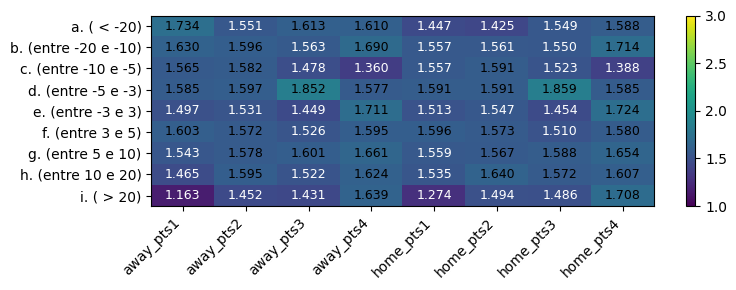

In [62]:
t = 200
df0\
.query("ref_remaining_time == @t")\
.drop(columns = "ref_remaining_time")\
.set_index("cat_dif")\
.pipe(heatmap_with_text, figsize = (8, 3), vmin = 1, vmax = 3)

In [61]:
def heatmap_with_text(df, cmap="viridis", fmt=".3f", figsize=(12,6), vmin = None, vmax = None):
    fig, ax = plt.subplots(figsize=figsize)

    data = df.values

    # Heatmap com escala fixa (se fornecida)
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)

    # Ticks
    ax.set_xticks(np.arange(df.shape[1]))
    ax.set_yticks(np.arange(df.shape[0]))

    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_yticklabels(df.index)

    # Texto dentro das células
    mid_val = np.nanmean(data)  # para escolher cor do texto
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, format(val, fmt),
                        ha="center", va="center",
                        color="white" if val < mid_val else "black",
                        fontsize=9)

    # Barra de cores
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()